In [8]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sys.path.append(str(Path.cwd().parent))
from src.data_loader import load_market_data
from src.features import build_feature_dataset

df_raw = load_market_data()
data, predictors = build_feature_dataset(df_raw)

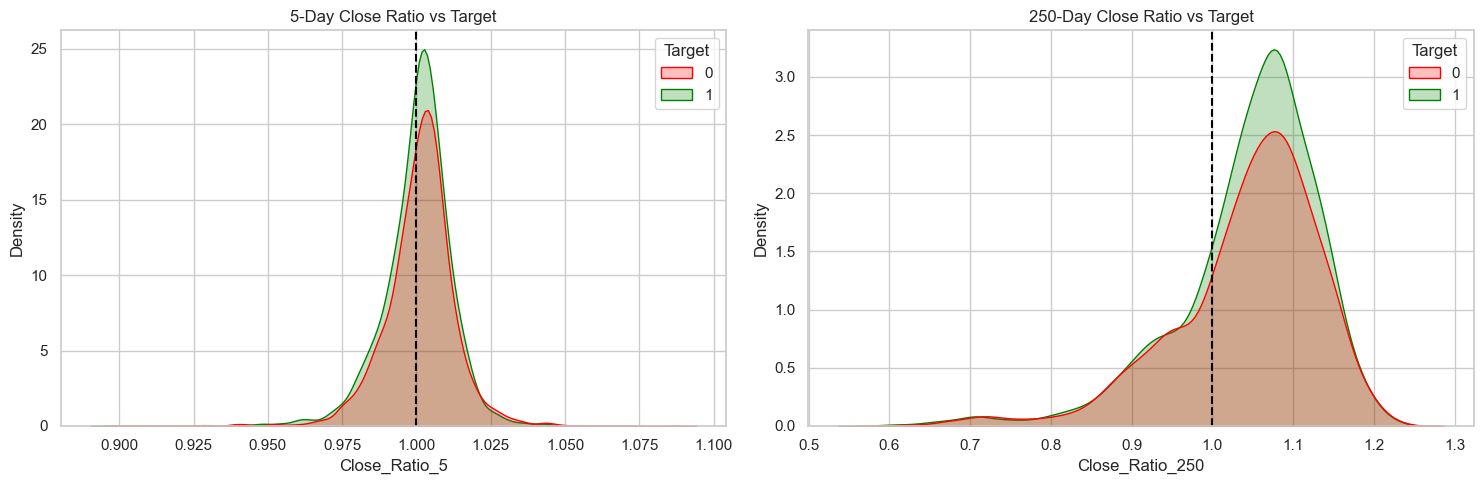

In [9]:
# Compare how a short-term ratio differs from a long-term ratio
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.kdeplot(data=data, x="Close_Ratio_5", hue="Target", fill=True, ax=axes[0], palette=['red', 'green'])
axes[0].set_title("5-Day Close Ratio vs Target")
axes[0].axvline(x=1.0, color='black', linestyle='--')

sns.kdeplot(data=data, x="Close_Ratio_250", hue="Target", fill=True, ax=axes[1], palette=['red', 'green'])
axes[1].set_title("250-Day Close Ratio vs Target")
axes[1].axvline(x=1.0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

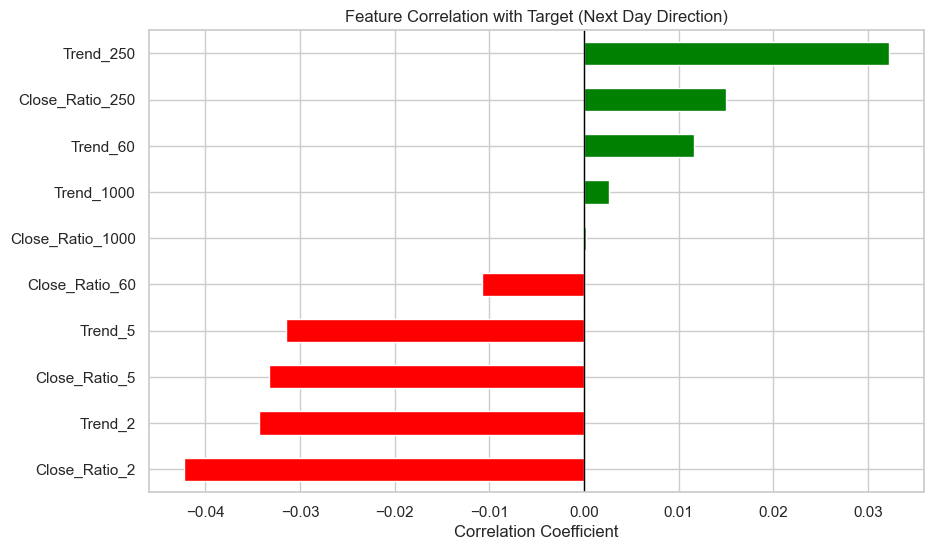

In [10]:
# Features that correlate most strongly with tomorrow's target
feature_cols = [col for col in data.columns if 'Ratio' in col or 'Trend' in col]

# Calculate correlation with the Target
correlations = data[feature_cols + ['Target']].corr()['Target'].drop('Target').sort_values()

plt.figure(figsize=(10, 6))
correlations.plot(kind='barh', color=np.where(correlations > 0, 'green', 'red'))
plt.title("Feature Correlation with Target (Next Day Direction)")
plt.xlabel("Correlation Coefficient")
plt.axvline(x=0, color='black', linewidth=1)
plt.show()

In [11]:
# Ensure 'Tomorrow' is NaN for the very last row, and Target is correctly shifted.
print("--- LAST 5 ROWS ---")
display(data[['Close', 'Tomorrow', 'Target', 'Trend_5']].tail())

print("\n--- SANITY CHECK ---")
# Check a random row in the middle to verify the math
random_idx = len(data) // 2
sample = data.iloc[random_idx:random_idx+2]
display(sample[['Close', 'Tomorrow', 'Target']])
print("Is 'Tomorrow' matching the next day's 'Close'? Should be exactly equal.")

--- LAST 5 ROWS ---


,Close,Tomorrow,Target,Trend_5
Date,,,,
2026-04-20,7109.140137,7064.009766,0,4.0
2026-04-21,7064.009766,7137.899902,1,3.0
2026-04-22,7137.899902,7108.399902,0,3.0
2026-04-23,7108.399902,7165.080078,1,2.0
2026-04-24,7165.080078,NaN,0,2.0



--- SANITY CHECK ---


,Close,Tomorrow,Target
Date,,,
2010-02-16,1094.869995,1099.51001,1
2010-02-17,1099.510010,1106.75000,1


Is 'Tomorrow' matching the next day's 'Close'? Should be exactly equal.
